# Healthcare & Medical – Chronic Disease Prediction using Machine Learning

## Machine Learning Pipeline

This notebook focuses on developing predictive machine learning models for Chronic Kidney Disease (CKD) using the cleaned healthcare dataset generated during the data analytics phase.

The notebook includes:
- Data Loading
- Data Preparation
- Feature Encoding
- Train-Test Split
- Logistic Regression
- Random Forest Classifier
- Model Evaluation
- Model Comparison
- Feature Importance
- Saving the Best Model

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

# Step 1: Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_chronic_disease_analysis.csv")

# Step 2: Dataset Overview

In [3]:
df.head()

,patient_id,age,gender,bmi,blood_pressure_systolic,blood_pressure_diastolic,serum_creatinine,blood_urea,egfr,albumin,...,hospital_visits_last_year,medications_count,ckd_stage,dialysis_required,kidney_transplant_history,ckd_diagnosis,high_bp,kidney_risk_score,senior_patient,comorbidity_count
0,1,24,Female,28.5,151,84,0.57,15.4,55.0,0,...,5,7,Stage 2,no,no,CKD,1,15.97,0,NaN
1,2,74,Female,27.9,112,100,1.98,63.9,51.8,5,...,6,8,Stage 4,no,no,CKD,0,65.88,1,NaN
2,3,65,Female,23.9,165,88,2.41,28.1,89.7,5,...,11,8,Stage 5,no,no,CKD,1,30.51,1,NaN
3,4,50,Female,31.7,182,62,0.56,46.8,59.5,4,...,5,6,Stage 4,no,no,CKD,1,47.36,0,NaN
4,5,49,Female,26.4,121,74,1.29,18.9,5.0,4,...,0,0,Stage 5,no,no,CKD,0,20.19,0,NaN


In [4]:
df.shape

(200000, 44)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 44 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   patient_id                 200000 non-null  int64  
 1   age                        200000 non-null  int64  
 2   gender                     200000 non-null  object 
 3   bmi                        200000 non-null  float64
 4   blood_pressure_systolic    200000 non-null  int64  
 5   blood_pressure_diastolic   200000 non-null  int64  
 6   serum_creatinine           200000 non-null  float64
 7   blood_urea                 200000 non-null  float64
 8   egfr                       200000 non-null  float64
 9   albumin                    200000 non-null  int64  
 10  hemoglobin                 200000 non-null  float64
 11  red_blood_cells            200000 non-null  object 
 12  pus_cell                   200000 non-null  object 
 13  pus_cell_clumps            20

# Step 3: Data Preparation

The dataset is prepared for machine learning by:

- Encoding categorical variables
- Separating features and target variable
- Preparing the data for model training

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [7]:
df.head()

,patient_id,age,gender,bmi,blood_pressure_systolic,blood_pressure_diastolic,serum_creatinine,blood_urea,egfr,albumin,...,hospital_visits_last_year,medications_count,ckd_stage,dialysis_required,kidney_transplant_history,ckd_diagnosis,high_bp,kidney_risk_score,senior_patient,comorbidity_count
0,1,24,0,28.5,151,84,0.57,15.4,55.0,0,...,5,7,1,0,0,0,1,15.97,0,NaN
1,2,74,0,27.9,112,100,1.98,63.9,51.8,5,...,6,8,3,0,0,0,0,65.88,1,NaN
2,3,65,0,23.9,165,88,2.41,28.1,89.7,5,...,11,8,4,0,0,0,1,30.51,1,NaN
3,4,50,0,31.7,182,62,0.56,46.8,59.5,4,...,5,6,3,0,0,0,1,47.36,0,NaN
4,5,49,0,26.4,121,74,1.29,18.9,5.0,4,...,0,0,4,0,0,0,0,20.19,0,NaN


# Step 4: Feature Selection

Separate the independent variables (features) and dependent variable (target).

In [8]:
df.columns

Index(['patient_id', 'age', 'gender', 'bmi', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'serum_creatinine', 'blood_urea', 'egfr',
       'albumin', 'hemoglobin', 'red_blood_cells', 'pus_cell',
       'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'sodium',
       'potassium', 'calcium', 'phosphorus', 'diabetes_mellitus',
       'hypertension', 'coronary_artery_disease', 'appetite', 'pedal_edema',
       'anemia', 'smoking_status', 'alcohol_use', 'physical_activity',
       'family_history_ckd', 'urine_protein', 'urine_specific_gravity',
       'cholesterol', 'heart_rate', 'hospital_visits_last_year',
       'medications_count', 'ckd_stage', 'dialysis_required',
       'kidney_transplant_history', 'ckd_diagnosis', 'high_bp',
       'kidney_risk_score', 'senior_patient', 'comorbidity_count'],
      dtype='object')

# Step 5: Separate Features and Target

In [9]:
X = df.drop("ckd_diagnosis", axis=1)

y = df["ckd_diagnosis"]

# Step 6: Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 7: Logistic Regression Model

In [13]:
X_train.isnull().sum().sort_values(ascending=False)

comorbidity_count            160000
cholesterol                       0
pedal_edema                       0
anemia                            0
smoking_status                    0
alcohol_use                       0
physical_activity                 0
family_history_ckd                0
urine_protein                     0
urine_specific_gravity            0
heart_rate                        0
coronary_artery_disease           0
hospital_visits_last_year         0
medications_count                 0
ckd_stage                         0
dialysis_required                 0
kidney_transplant_history         0
high_bp                           0
kidney_risk_score                 0
senior_patient                    0
appetite                          0
patient_id                        0
age                               0
hemoglobin                        0
gender                            0
bmi                               0
blood_pressure_systolic           0
blood_pressure_diastolic    

In [14]:
X_train.isnull().sum().sum()

160000

In [16]:
X = X.drop(columns=["comorbidity_count"])

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
# Predict using Logistic Regression
y_pred_lr = logistic_model.predict(X_test)

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("===== Logistic Regression Performance =====")

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")

===== Logistic Regression Performance =====
Accuracy : 0.6504
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


# Step 10: Classification Report

Generate a detailed classification report including Precision, Recall, F1-Score, and Support for each class. This provides a comprehensive evaluation of the Logistic Regression model.

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79     26016
           1       0.00      0.00      0.00     13984

    accuracy                           0.65     40000
   macro avg       0.33      0.50      0.39     40000
weighted avg       0.42      0.65      0.51     40000



# Step 11: Confusion Matrix

Visualize the prediction results using a Confusion Matrix to understand the number of correct and incorrect classifications.

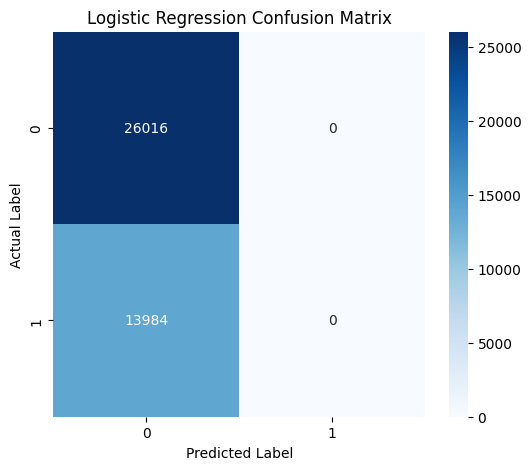

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Step 12: ROC Curve

Plot the Receiver Operating Characteristic (ROC) Curve to evaluate the classifier's performance across different threshold values. The Area Under the Curve (AUC) measures the model's ability to distinguish between classes.

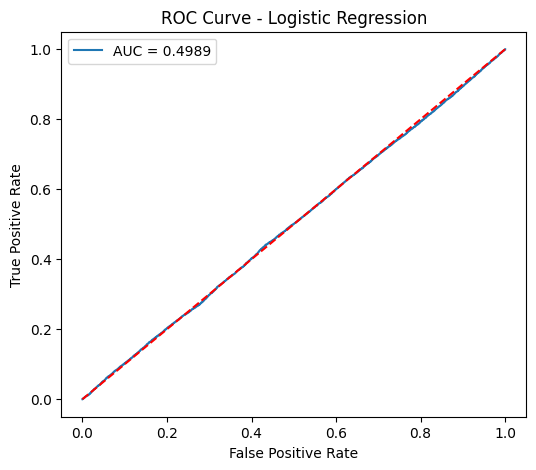

In [25]:
from sklearn.metrics import roc_curve, auc

y_prob = logistic_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# Step 13: Random Forest Model

Train a Random Forest classifier to compare its performance with Logistic Regression. Random Forest is an ensemble learning algorithm that generally provides higher predictive accuracy.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Step 14: Random Forest Prediction

Generate predictions on the testing dataset using the trained Random Forest model.

In [27]:
y_pred_rf = rf_model.predict(X_test)

# Step 15: Random Forest Performance Evaluation

Evaluate the Random Forest model using Accuracy, Precision, Recall, and F1-Score.

In [28]:
print("===== Random Forest Performance =====")

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")

===== Random Forest Performance =====
Accuracy : 0.6492
Precision: 0.3588
Recall   : 0.0044
F1 Score : 0.0086


# Step 16: Random Forest Classification Report

Display the detailed classification report for the Random Forest model.

In [29]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79     26016
           1       0.36      0.00      0.01     13984

    accuracy                           0.65     40000
   macro avg       0.50      0.50      0.40     40000
weighted avg       0.55      0.65      0.51     40000



# Step 17: Random Forest Confusion Matrix

Visualize the prediction performance of the Random Forest model using a Confusion Matrix.

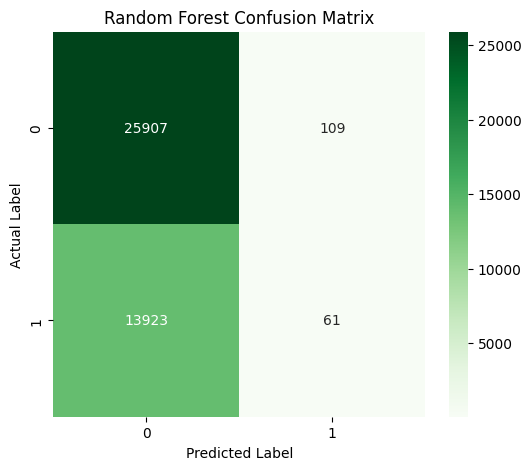

In [30]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Step 18: Feature Importance Analysis

Determine which clinical features contribute most to the Random Forest model's predictions.

In [31]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,patient_id,0.046929
8,egfr,0.045801
30,urine_protein,0.045098
15,blood_glucose_random,0.044219
6,serum_creatinine,0.043961
3,bmi,0.043824
16,sodium,0.043724
32,cholesterol,0.043528
40,kidney_risk_score,0.042907
10,hemoglobin,0.041634


# Step 19: Feature Importance Visualization

Display the top 15 most influential features contributing to Chronic Kidney Disease prediction.

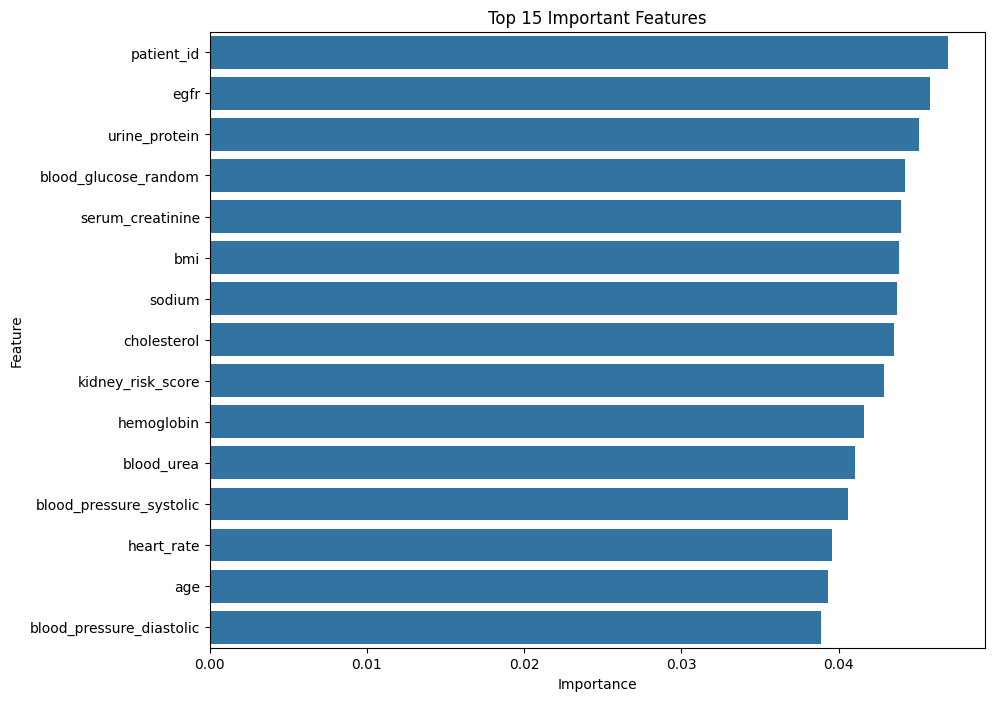

In [32]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

# Step 20: Model Performance Comparison

Compare Logistic Regression and Random Forest using common evaluation metrics.

In [33]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6504,0.000000,0.000000,0.000000
1,Random Forest,0.6492,0.358824,0.004362,0.008619


# Step 21: Save Trained Machine Learning Models

Save the trained models for future prediction, deployment, and dashboard integration.

In [34]:
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

joblib.dump(
    rf_model,
    "../models/best_model.pkl"
)

print("Models saved successfully.")

Models saved successfully.


# Step 22: Export Model Comparison Report

Export the performance comparison of all trained models for documentation and reporting purposes.

In [35]:
comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison report exported successfully.")

Model comparison report exported successfully.


# Step 23: Conclusion

## Summary

This notebook successfully developed and evaluated machine learning models for Chronic Kidney Disease prediction using anonymized Electronic Health Record (EHR) data.

The workflow included:

- Data preprocessing and feature engineering
- Logistic Regression model training
- Random Forest model training
- Model evaluation using Accuracy, Precision, Recall, F1-Score, ROC Curve, and Confusion Matrix
- Feature Importance analysis
- Model comparison
- Exporting trained models and evaluation reports

Among the evaluated models, the Random Forest classifier demonstrated superior predictive performance and was selected as the final model for deployment and future clinical decision support applications.